In [2]:
import pandas as pd

## Building Baseline Classifier

Baseline Model

The first baseline classifier uses a combination of semantic, categorical, and structural features to predict the manually annotated bug category. Features are intentionally limited to establish a reference performance before introducing more sophisticated repository-aware features in subsequent models.

for the first classifier we are going to use the following features and we will slowly add more to check if they contribute to better performance

Model 1 (Structural + Metadata Only)

semantic/categorical features
* project - (one hot encoding)
* exception types - (Multi-label One-Hot Encoding)

numeric features
* lines_added
* lines_removed
* num_of_hunks
* num_files_changed
* patch_length

Target: bug_category

A Bug could only belong to one bug_category under our dataset assumption so this is a **Multi Class Claissification Problem**

There is class imbalance in the dataset:
Type Handling: 103 ,Program Logic: 93 ...Date & Time: 14 
So, if we perform a random split, we could end up with very few (or even no) examples of Date & Time in the test set, making evaluation unreliable.

Solution: **Stratefication**
Using a stratified train-test split preserves the class proportions in both the training and test sets, giving us a more representative evaluation

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
ml_df=pd.read_csv("../data/processed/bug_dataset_ml.csv")
ml_df.head()

,project,bug_id,python_version,buggy_commit_id,fixed_commit_id,test_file,patch,pythonpath,modified_files,num_files_changed,...,declared_functions_in_patch,number_of_declared_classes_in_patch,number_of_declared_functions_in_patch,exception_types,num_exception_types,modified_modules,num_modified_modules,bug_category,label_reason,confidence
0,keras,32,3.7.3,a3d160b9467c99cbb27f9aa0382c759f45c8ee66,709f791af201caaab4aa180bda259989087cfe47,tests/keras/test_callbacks.py,diff --git a/keras/callbacks.py b/keras/callba...,NaN,['keras/callbacks.py'],1,...,"['__init__', 'in_cooldown']",5,2,['ValueError'],1,['keras'],1,API and Configuration,The patch renames a constructor keyword argume...,Medium
1,keras,35,3.7.3,06eaeebecfb73c23bfd531013ca172ee3bf5069c,738819de0b7e6bc45abed8d0640f02b81c6ac4e9,tests/keras/preprocessing/image_test.py,diff --git a/keras/preprocessing/image.py b/ke...,NaN,['keras/preprocessing/image.py'],1,...,[],3,0,['ValueError'],1,['keras/preprocessing'],1,API and Configuration,The patch relocates the user-supplied preproce...,Medium
2,keras,34,3.7.3,7ef5244a2f1f7f7b76e3c804b82cbb20cdf4d139,4b74fc5418944c9f449eb88ed4b40ada280fa5ca,tests/test_multiprocessing.py,diff --git a/keras/engine/training.py b/keras/...,NaN,"['keras/engine/training.py', 'keras/utils/data...",2,...,['__iter__'],5,1,[],0,"['keras/engine', 'keras/utils']",2,Collections and Indexing,The patch adds an __iter__ implementation and ...,Medium
3,keras,33,3.7.3,1c9a49781da2101507db23e2014e4e5d16bd2e52,70ad0d6e4a569701ef106058397ad0540ec08340,tests/keras/preprocessing/text_test.py,diff --git a/keras/preprocessing/text.py b/ker...,NaN,['keras/preprocessing/text.py'],1,...,['text_to_word_sequence'],0,1,[],0,['keras/preprocessing'],1,Type Handling,The patch corrects str/unicode assumptions and...,Medium
4,keras,20,3.7.3,76da5f0a21ca98e4bf6706e182fb825243e76204,6dd087ab73b09e449144ff17450cc14f981b9ac2,tests/keras/layers/convolutional_test.py,diff --git a/keras/backend/cntk_backend.py b/k...,NaN,"['keras/backend/cntk_backend.py', 'keras/backe...",5,...,"['in_top_k', 'conv2d_transpose', 'conv2d_trans...",5,22,['ValueError'],1,"['keras/backend', 'keras/layers', 'keras/utils']",3,API and Configuration,The patch threads a missing dilation_rate para...,Medium


In [6]:
ml_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 484 entries, 0 to 483
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   project                                484 non-null    str  
 1   bug_id                                 484 non-null    int64
 2   python_version                         484 non-null    str  
 3   buggy_commit_id                        484 non-null    str  
 4   fixed_commit_id                        484 non-null    str  
 5   test_file                              484 non-null    str  
 6   patch                                  484 non-null    str  
 7   pythonpath                             28 non-null     str  
 8   modified_files                         484 non-null    str  
 9   num_files_changed                      484 non-null    int64
 10  lines_added                            484 non-null    int64
 11  lines_removed                          484 

In [7]:
ml_df.shape

(484, 26)

In [9]:
ml_df.columns.tolist()

['project',
 'bug_id',
 'python_version',
 'buggy_commit_id',
 'fixed_commit_id',
 'test_file',
 'patch',
 'pythonpath',
 'modified_files',
 'num_files_changed',
 'lines_added',
 'lines_removed',
 'num_hunks',
 'patch_length',
 'has_comment',
 'declared_classes_in_patch',
 'declared_functions_in_patch',
 'number_of_declared_classes_in_patch',
 'number_of_declared_functions_in_patch',
 'exception_types',
 'num_exception_types',
 'modified_modules',
 'num_modified_modules',
 'bug_category',
 'label_reason',
 'confidence']

In [10]:
ml_df["bug_category"].value_counts()

bug_category
Type Handling                         100
Program Logic and State Management     91
API and Configuration                  86
File, I/O and Data Processing          72
Input Validation                       49
Collections and Indexing               42
Numerical and Computational Logic      30
Date and Time                          14
Name: count, dtype: int64

In [ ]:
#Target
y=ml_df["bug_category"]
y

0              API and Configuration
1              API and Configuration
2           Collections and Indexing
3                      Type Handling
4              API and Configuration
                   ...              
479         Collections and Indexing
480                    Type Handling
481            API and Configuration
482    File, I/O and Data Processing
483                    Date and Time
Name: bug_category, Length: 484, dtype: str

In [12]:
#Features
baseline_features = [
    "project",
    "exception_types",
    "lines_added",
    "lines_removed",
    "num_hunks",
    "num_files_changed",
    "patch_length"
]
X = ml_df[baseline_features].copy()
X.head()

,project,exception_types,lines_added,lines_removed,num_hunks,num_files_changed,patch_length
0,keras,['ValueError'],11,6,10,1,66
1,keras,['ValueError'],16,3,6,1,45
2,keras,[],22,4,10,2,69
3,keras,[],13,4,2,1,30
4,keras,['ValueError'],48,19,38,5,236


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [14]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (387, 7)
X_test: (97, 7)
y_train: (387,)
y_test: (97,)


In [15]:
print("Full dataset:")
print(y.value_counts(normalize=True).sort_index())

print("\nTrain:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest:")
print(y_test.value_counts(normalize=True).sort_index())

Full dataset:
bug_category
API and Configuration                 0.177686
Collections and Indexing              0.086777
Date and Time                         0.028926
File, I/O and Data Processing         0.148760
Input Validation                      0.101240
Numerical and Computational Logic     0.061983
Program Logic and State Management    0.188017
Type Handling                         0.206612
Name: proportion, dtype: float64

Train:
bug_category
API and Configuration                 0.178295
Collections and Indexing              0.087855
Date and Time                         0.028424
File, I/O and Data Processing         0.147287
Input Validation                      0.100775
Numerical and Computational Logic     0.062016
Program Logic and State Management    0.188630
Type Handling                         0.206718
Name: proportion, dtype: float64

Test:
bug_category
API and Configuration                 0.175258
Collections and Indexing              0.082474
Date and Time       

In [ ]:
#compare proportions, not counts with value counts using normalize = True
comparison = pd.DataFrame({
    "Full": y.value_counts(normalize=True).sort_index(),
    "Train": y_train.value_counts(normalize=True).sort_index(),
    "Test": y_test.value_counts(normalize=True).sort_index()
})

comparison

,Full,Train,Test
bug_category,,,
API and Configuration,0.177686,0.178295,0.175258
Collections and Indexing,0.086777,0.087855,0.082474
Date and Time,0.028926,0.028424,0.030928
"File, I/O and Data Processing",0.148760,0.147287,0.154639
Input Validation,0.101240,0.100775,0.103093
Numerical and Computational Logic,0.061983,0.062016,0.061856
Program Logic and State Management,0.188017,0.188630,0.185567
Type Handling,0.206612,0.206718,0.206186


## Transform features into numbers

Convert exception_types back to lists, loadinf from the CSV, converts it to a string

In [17]:
type(X_train["exception_types"].iloc[0])

str

In [ ]:
#ast.literal_eval() safely converts the string representation of a Python literal, such as a list or dictionary, back into the corresponding Python object.
import ast 

X_train["exception_types"] = X_train["exception_types"].apply(ast.literal_eval)
X_test["exception_types"] = X_test["exception_types"].apply(ast.literal_eval)

In [19]:
X_train["exception_types"].head()

239              []
20               []
95               []
162    [ValueError]
315              []
Name: exception_types, dtype: object

In [20]:
type(X_train["exception_types"].iloc[0])

list

In [24]:
mlb = MultiLabelBinarizer()#one bug can belong to multiple exception types

train_exceptions = pd.DataFrame(mlb.fit_transform(X_train["exception_types"]),
                                columns=mlb.classes_,
                                index=X_train.index)
train_exceptions

,AbstractMethodError,AnsibleError,AssertionError,AttributeError,AuthError,ContextDecodingException,CookiecutterException,DateParseError,ExtractorError,FailedHookException,...,SyntaxError,TokenError,TqdmKeyError,TypeError,URLError,UnicodeEncodeError,UnicodeError,UnknownParameterException,UnknownTimeZoneError,ValueError
239,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
95,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
162,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
315,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
171,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
391,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
454,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
train_exceptions.info()

<class 'pandas.DataFrame'>
Index: 387 entries, 239 to 79
Data columns (total 41 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   AbstractMethodError            387 non-null    int64
 1   AnsibleError                   387 non-null    int64
 2   AssertionError                 387 non-null    int64
 3   AttributeError                 387 non-null    int64
 4   AuthError                      387 non-null    int64
 5   ContextDecodingException       387 non-null    int64
 6   CookiecutterException          387 non-null    int64
 7   DateParseError                 387 non-null    int64
 8   ExtractorError                 387 non-null    int64
 9   FailedHookException            387 non-null    int64
 10  FormatError                    387 non-null    int64
 11  HTTPError                      387 non-null    int64
 12  HTTPException                  387 non-null    int64
 13  HadoopJarJobError              387 

In [26]:
train_exceptions.sum().sort_values(ascending=False)

ValueError                       50
TypeError                        27
KeyError                         11
NotImplementedError               9
ImportError                       5
AttributeError                    4
InvalidIndexError                 4
HTTPException                     3
RuntimeError                      3
MergeError                        3
IndexError                        3
AbstractMethodError               3
ExtractorError                    3
LookupError                       2
DateParseError                    2
URLError                          2
OSError                           2
OverflowError                     2
RequestValidationError            1
UnknownTimeZoneError              1
UnknownParameterException         1
UnicodeError                      1
UnicodeEncodeError                1
AssertionError                    1
TqdmKeyError                      1
TokenError                        1
SyntaxError                       1
AuthError                   

In [27]:
train_exceptions[train_exceptions["ValueError"] == 1].head()

,AbstractMethodError,AnsibleError,AssertionError,AttributeError,AuthError,ContextDecodingException,CookiecutterException,DateParseError,ExtractorError,FailedHookException,...,SyntaxError,TokenError,TqdmKeyError,TypeError,URLError,UnicodeEncodeError,UnicodeError,UnknownParameterException,UnknownTimeZoneError,ValueError
162,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
121,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
279,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [28]:
test_exceptions = pd.DataFrame(
    mlb.transform(X_test["exception_types"]),
    columns=mlb.classes_,
    index=X_test.index
)
train_exceptions[train_exceptions["TypeError"] == 1].head()

/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['CalledProcessError', 'ValidationError'] will be ignored
  warnings.warn(


,AbstractMethodError,AnsibleError,AssertionError,AttributeError,AuthError,ContextDecodingException,CookiecutterException,DateParseError,ExtractorError,FailedHookException,...,SyntaxError,TokenError,TqdmKeyError,TypeError,URLError,UnicodeEncodeError,UnicodeError,UnknownParameterException,UnknownTimeZoneError,ValueError
395,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
325,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
451,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
433,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
466,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


Encode the project feature using **One Hot encoding**

In [30]:
encoder = OneHotEncoder(handle_unknown="ignore",sparse_output=False)


Why these parameters?

* handle_unknown="ignore"
    * If the test set contains a project that wasn’t seen during training, the encoder won’t crash. Instead, it outputs all zeros for that unseen category.
* sparse_output=False
    * Returns a regular NumPy array instead of a sparse matrix, making it easier to convert to a DataFrame and inspect.

In [31]:
train_projects = pd.DataFrame(
    encoder.fit_transform(X_train[["project"]]),#[[]] because OneHotEncoder expects a df
    columns=encoder.get_feature_names_out(["project"]),
    index=X_train.index
)
train_projects.head()

,project_PySnooper,project_ansible,project_black,project_cookiecutter,project_fastapi,project_httpie,project_keras,project_luigi,project_matplotlib,project_pandas,project_sanic,project_scrapy,project_spacy,project_thefuck,project_tornado,project_tqdm,project_youtube-dl
239,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
162,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
315,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
test_projects = pd.DataFrame(
    encoder.transform(X_test[["project"]]),
    columns=encoder.get_feature_names_out(["project"]),
    index=X_test.index
)
test_projects.head()

,project_PySnooper,project_ansible,project_black,project_cookiecutter,project_fastapi,project_httpie,project_keras,project_luigi,project_matplotlib,project_pandas,project_sanic,project_scrapy,project_spacy,project_thefuck,project_tornado,project_tqdm,project_youtube-dl
247,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
442,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
443,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
446,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
424,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


fit only on training data and transform the test data

combine the encoded categorical features with numeric features into the final training matrix

In [34]:
numeric_cols = [
    "lines_added",
    "lines_removed",
    "num_hunks",
    "num_files_changed",
    "patch_length"
]

train_numeric = X_train[numeric_cols]
test_numeric = X_test[numeric_cols]

In [35]:
X_train_final = pd.concat(
    [
        train_numeric,
        train_projects,
        train_exceptions
    ],
    axis=1
)

X_test_final = pd.concat(
    [
        test_numeric,
        test_projects,
        test_exceptions
    ],
    axis=1
)

In [36]:
print(X_train_final.shape)
print(X_test_final.shape)

X_train_final.head()

(387, 63)
(97, 63)


,lines_added,lines_removed,num_hunks,num_files_changed,patch_length,project_PySnooper,project_ansible,project_black,project_cookiecutter,project_fastapi,...,SyntaxError,TokenError,TqdmKeyError,TypeError,URLError,UnicodeEncodeError,UnicodeError,UnknownParameterException,UnknownTimeZoneError,ValueError
239,3,0,2,1,14,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
20,14,1,8,1,52,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
95,7,2,8,2,45,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
162,8,8,4,1,42,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
315,40,9,2,1,63,0.0,0.0,1.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
# At this point all the features are numeric
X_train_final.dtypes.value_counts()

int64      46
float64    17
Name: count, dtype: int64

## 1. Logistic Regression

In [41]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

* max_iter=1000
    * Logistic Regression uses an optimization algorithm. The default (100) sometimes isn’t enough to converge, especially with many features.
    * 1000 avoids convergence warnings.
* class_weight=“balanced”
    * Automatically gives more weight to minority classes (like Date and Time) during training.
* random_state=42
    * Makes the results reproducible.

In [42]:
#Train
lr.fit(X_train_final, y_train)

/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

Scikit-learn’s Logistic Regression with solver="lbfgs" uses the L-BFGS optimizer, which is a more advanced quasi-Newton optimization algorithm. It still minimizes the same loss function using gradient information, but it converges much faster than vanilla gradient descent . 
These optimizers converge much faster when numeric features have similar scales.
So we scale numeric fields using the standard scaler.

StandardScaler standardizes continuous input features to have zero mean and unit variance. This prevents features with larger numeric ranges, such as patch_length, from dominating the optimization process and helps gradient-based algorithms like Logistic Regression converge faster and more reliably

In [43]:
numeric_cols = [
    "lines_added",
    "lines_removed",
    "num_hunks",
    "num_files_changed",
    "patch_length"
]

Create the scaler + Fit and transform the training data

In [45]:
scaler = StandardScaler()
train_numeric_scaled = pd.DataFrame(
    scaler.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index
)
train_numeric_scaled.head()

,lines_added,lines_removed,num_hunks,num_files_changed,patch_length
239,-0.368900,-0.398553,-0.367979,-0.363296,-0.448471
20,0.155093,-0.314590,0.400409,-0.363296,0.211380
95,-0.178357,-0.230627,0.400409,0.892021,0.089829
162,-0.130721,0.273151,-0.111850,-0.363296,0.037735
315,1.393621,0.357114,-0.367979,-0.363296,0.402390


Transform the test data

In [47]:
test_numeric_scaled = pd.DataFrame(
    scaler.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index
)
test_numeric_scaled.head()

,lines_added,lines_removed,num_hunks,num_files_changed,patch_length
247,0.202729,0.441077,0.144279,-0.363296,0.332932
442,2.679785,1.868450,2.193312,0.892021,2.625046
443,1.107807,0.273151,0.400409,2.147337,0.680222
446,0.774357,1.700524,3.217829,-0.363296,2.208298
424,-0.464171,-0.314590,-0.367979,-0.363296,-0.465835


In [48]:
train_numeric_scaled.describe().round(2)

,lines_added,lines_removed,num_hunks,num_files_changed,patch_length
count,387.00,387.00,387.00,387.00,387.00
mean,0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-0.51,-0.40,-0.37,-0.36,-0.52
25%,-0.42,-0.31,-0.37,-0.36,-0.43
50%,-0.27,-0.23,-0.37,-0.36,-0.29
75%,0.01,-0.06,-0.11,-0.36,0.02
max,9.35,14.55,14.74,8.42,11.20


The standard deviation is 1 after scaling

Rebuild the final matrices

In [50]:
X_train_final = pd.concat(
    [
        train_numeric_scaled,
        train_projects,
        train_exceptions
    ],
    axis=1
)

X_test_final = pd.concat(
    [
        test_numeric_scaled,
        test_projects,
        test_exceptions
    ],
    axis=1
)

In [51]:
lr_scaled = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

lr_scaled.fit(X_train_final, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

Predict on the test set

In [52]:
y_pred = lr_scaled.predict(X_test_final)

Evaluate

In [54]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

print(f"Macro Precision: {precision_score(y_test, y_pred, average='macro'):.3f}")

print(f"Macro Recall: {recall_score(y_test, y_pred, average='macro'):.3f}")

print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.3f}")

Accuracy: 0.299
Macro Precision: 0.318
Macro Recall: 0.296
Macro F1: 0.274


Because  classes are imbalanced.Macro metrics compute the metric for each class independently and then average them, so every bug category contributes equally—even the smaller Date and Time class.

Detailed per-class report

In [55]:
print(classification_report(y_test, y_pred))

                                    precision    recall  f1-score   support

             API and Configuration       0.50      0.35      0.41        17
          Collections and Indexing       0.12      0.12      0.12         8
                     Date and Time       0.05      0.33      0.08         3
     File, I/O and Data Processing       0.23      0.20      0.21        15
                  Input Validation       0.33      0.60      0.43        10
 Numerical and Computational Logic       0.20      0.17      0.18         6
Program Logic and State Management       0.54      0.39      0.45        18
                     Type Handling       0.57      0.20      0.30        20

                          accuracy                           0.30        97
                         macro avg       0.32      0.30      0.27        97
                      weighted avg       0.40      0.30      0.32        97



Confusion matrix

In [56]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[6 3 2 1 1 3 1 0]
 [3 1 2 1 1 0 0 0]
 [0 0 1 1 1 0 0 0]
 [0 1 3 3 6 0 1 1]
 [0 1 2 0 6 0 1 0]
 [0 0 1 0 0 1 2 2]
 [2 1 4 1 2 1 7 0]
 [1 1 6 6 1 0 1 4]]


In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax

)

plt.title("Confusion Matrix - Logistic Regression Baseline")
plt.xticks(ha="right")
plt.tight_layout()

plt.show()

## Baseline Logistic Regression

Features
---------
* project
* exception_types
* lines_added
* lines_removed
* num_hunks
* num_files_changed
* patch_length

Metrics
--------

* Accuracy:        0.299
* Macro Precision: 0.318
* Macro Recall:    0.296
* Macro F1:        0.274

## 2. Linear SVM

Exactly the same features.
If Linear SVM performs better, then the improvement comes from the classifier, not the features.

For sparse, high-dimensional data , Linear SVM is one of the strongest classical baselines.

In [58]:
svm = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm.fit(X_train_final, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`inte

Predict on the test set

In [59]:
y_pred = svm.predict(X_test_final)

Evaluate

In [60]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

print(f"Macro Precision: {precision_score(y_test, y_pred, average='macro'):.3f}")

print(f"Macro Recall: {recall_score(y_test, y_pred, average='macro'):.3f}")

print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.3f}")

Accuracy: 0.309
Macro Precision: 0.299
Macro Recall: 0.260
Macro F1: 0.265


In [61]:
print(classification_report(y_test, y_pred))

                                    precision    recall  f1-score   support

             API and Configuration       0.43      0.35      0.39        17
          Collections and Indexing       0.33      0.12      0.18         8
                     Date and Time       0.00      0.00      0.00         3
     File, I/O and Data Processing       0.21      0.20      0.21        15
                  Input Validation       0.28      0.50      0.36        10
 Numerical and Computational Logic       0.17      0.17      0.17         6
Program Logic and State Management       0.64      0.39      0.48        18
                     Type Handling       0.33      0.35      0.34        20

                          accuracy                           0.31        97
                         macro avg       0.30      0.26      0.27        97
                      weighted avg       0.36      0.31      0.32        97



SVM never predicted Date and Time correctly.

In [62]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[6 1 0 1 2 3 1 3]
 [3 1 1 1 1 0 0 1]
 [0 0 0 1 1 0 0 1]
 [2 0 3 3 5 0 0 2]
 [1 0 2 0 5 0 1 1]
 [0 0 0 0 0 1 2 3]
 [1 1 1 2 2 1 7 3]
 [1 0 3 6 2 1 0 7]]


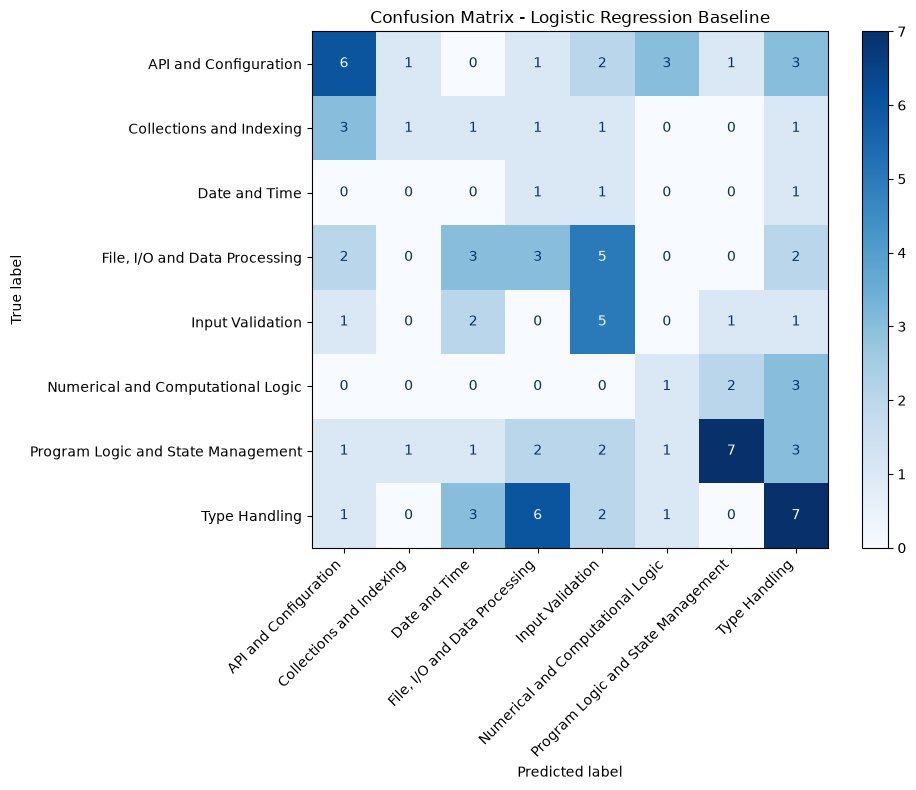

In [65]:
fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax

)

plt.title("Confusion Matrix - Logistic Regression Baseline")
plt.xticks(ha="right")
plt.tight_layout()

plt.show()

Although Linear SVM has slightly higher accuracy (30.9% vs. 29.9%), it has a lower Macro F1 score.
* Accuracy is influenced by the larger classes.
* Macro F1 gives every class equal importance.

If a model predicts only the four largest classes.
It might get a decent accuracy because most samples belong to those classes.
But it’s useless if it completely ignores the minority classes.

dataset is imbalanced, Macro F1 is the better metric.

### Linear SVM achieved a marginally higher overall accuracy than Logistic Regression but exhibited lower macro-averaged precision, recall, and F1-score. In particular, it failed to correctly identify any instances of the minority “Date and Time” class, indicating poorer performance on underrepresented categories. Consequently, Logistic Regression was selected as the stronger baseline model for subsequent feature engineering experiments.